In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123)

# Output folder for report images (absolute path for reliability)
IMAGES_DIR = "/Users/AnranSeverac/SimulationMethods/Images"
os.makedirs(IMAGES_DIR, exist_ok=True)
print(f"Saving figures to: {IMAGES_DIR}")

# Parameters (European call, GBM — match Giles 2008 §6.1.1)
r_mlmc = 0.05
sigma_mlmc = 0.2
T_mlmc = 1.0
S0_mlmc = 1.0
K_mlmc = 1.0
M = 4  # refinement factor (paper uses M=4)

Saving figures to: /Users/AnranSeverac/SimulationMethods/Images


In [17]:
def euler_gbm_path(S0, r, sigma, T, dW):
    """Single Euler path: S_{n+1} = S_n + r*S_n*h + sigma*S_n*dW_n. dW shape (n_steps,). Returns S_T."""
    n = len(dW)
    h = T / n
    S = S0
    for i in range(n):
        S = S + r * S * h + sigma * S * dW[i]
    return S

def euler_gbm_path_full(S0, r, sigma, T, dW):
    """Euler path returning full trajectory (for Asian etc). dW shape (n_steps,)."""
    n = len(dW)
    h = T / n
    S = np.zeros(n + 1)
    S[0] = S0
    for i in range(n):
        S[i + 1] = S[i] + r * S[i] * h + sigma * S[i] * dW[i]
    return S

def payoff_european(S_T, K, r, T):
    """Discounted European call payoff."""
    return np.exp(-r * T) * np.maximum(S_T - K, 0.0)

In [18]:
def mlmc_coupled_paths(l, S0, r, sigma, T, K, M, seed=None):
    """
    One coupled (fine, coarse) path at level l.
    Fine: timestep h_l = T/M^l, coarse: h_{l-1} = T/M^{l-1}.
    Same Brownian path: coarse increments = sum of M fine increments.
    Returns (P_l, P_{l-1}) for European call.
    """
    if seed is not None:
        np.random.seed(seed)
    n_fine = M ** l
    h_fine = T / n_fine
    dW_fine = np.random.standard_normal(n_fine) * np.sqrt(h_fine)
    S_fine = euler_gbm_path(S0, r, sigma, T, dW_fine)
    if l == 0:
        return payoff_european(S_fine, K, r, T), 0.0  # level 0: no coarse path
    # Coarse: sum fine increments in groups of M
    dW_coarse = dW_fine.reshape(-1, M).sum(axis=1)
    S_coarse = euler_gbm_path(S0, r, sigma, T, dW_coarse)
    P_fine = payoff_european(S_fine, K, r, T)
    P_coarse = payoff_european(S_coarse, K, r, T)
    return P_fine, P_coarse

def mlmc_level_samples(l, N, S0, r, sigma, T, K, M, seed=None):
    """N coupled samples at level l. Returns (diffs, mean_diff, fine_payoffs)."""
    if seed is not None:
        np.random.seed(seed)
    if l == 0:
        out = np.array([mlmc_coupled_paths(0, S0, r, sigma, T, K, M)[0] for _ in range(N)])
        return out, np.mean(out), out  # P_0, mean, and "fine" = P_0
    diffs = np.zeros(N)
    fine_payoffs = np.zeros(N)
    for i in range(N):
        Pf, Pc = mlmc_coupled_paths(l, S0, r, sigma, T, K, M)
        diffs[i] = Pf - Pc
        fine_payoffs[i] = Pf
    return diffs, np.mean(diffs), fine_payoffs

In [19]:
def run_mlmc(eps, S0, r, sigma, T, K, M, N_pilot=2000):
    """
    MLMC algorithm (Giles §5). Target RMSE epsilon; cost = total timesteps.
    Returns: (L, N_l list, Y_hat, cost, V_est, Y_est).
    """
    L = 0
    V_est, Y_est = {}, {}
    while True:
        # Pilot at new level L
        if L == 0:
            s0, _, _ = mlmc_level_samples(0, N_pilot, S0, r, sigma, T, K, M)
            V_est[0] = np.var(s0)
            Y_est[0] = np.mean(s0)
        else:
            sL, _, _ = mlmc_level_samples(L, N_pilot, S0, r, sigma, T, K, M)
            V_est[L] = np.var(sL)
            Y_est[L] = np.mean(sL)
        # Optimal N_l (eq 12)
        sum_sqrt = sum(np.sqrt(V_est[l] * (T / M**l)) for l in range(L + 1))
        sum_sqrt = max(sum_sqrt, 1e-20)
        N_opt = []
        for l in range(L + 1):
            hl = T / (M ** l)
            n_l = int(np.ceil(2 * (eps**-2) * np.sqrt(V_est[l] * hl) / sum_sqrt))
            N_opt.append(max(n_l, 100))
        # Run N_opt[l] samples at each level and recompute mean/var
        for l in range(L + 1):
            if l == 0:
                s0, _, _ = mlmc_level_samples(0, N_opt[0], S0, r, sigma, T, K, M)
                Y_est[0], V_est[0] = np.mean(s0), np.var(s0)
            else:
                sl, _, _ = mlmc_level_samples(l, N_opt[l], S0, r, sigma, T, K, M)
                Y_est[l], V_est[l] = np.mean(sl), np.var(sl)
        cost = N_opt[0] * 1 + sum(N_opt[l] * (M**l + M**(l-1)) for l in range(1, L + 1))
        # Bias check (eq 10)
        thresh = (1 / np.sqrt(2)) * (M - 1) * eps
        if L >= 2:
            if max(abs(Y_est[L]) * 1.0, abs(Y_est.get(L - 1, 0)) / M) < thresh:
                break
        if L >= 5:
            break
        L += 1
    Y_hat = sum(Y_est[l] for l in range(L + 1))
    return L, N_opt, Y_hat, cost, V_est, Y_est

In [20]:
# Single MLMC run at target accuracy epsilon
eps_target = 0.001
L, N_list, Y_hat, cost, V_est, Y_est = run_mlmc(
    eps_target, S0_mlmc, r_mlmc, sigma_mlmc, T_mlmc, K_mlmc, M, N_pilot=2000
)
print(f"Target epsilon = {eps_target}")
print(f"Levels L = 0..{L}, N_l = {N_list}")
print(f"MLMC estimate Y_hat = {Y_hat:.6f}")
print(f"Total cost (timesteps) = {cost:.0f}")
print(f"V_l (sample var of P_l - P_{{l-1}}) = {[round(V_est[l], 8) for l in range(L+1)]}")

Target epsilon = 0.001
Levels L = 0..2, N_l = [1814224, 151666, 34111]
MLMC estimate Y_hat = 0.104257
Total cost (timesteps) = 3254774
V_l (sample var of P_l - P_{l-1}) = [np.float64(0.01611468), np.float64(0.00044827), np.float64(0.00010439)]


Saved: /Users/AnranSeverac/SimulationMethods/Images/var_bias_decay.png


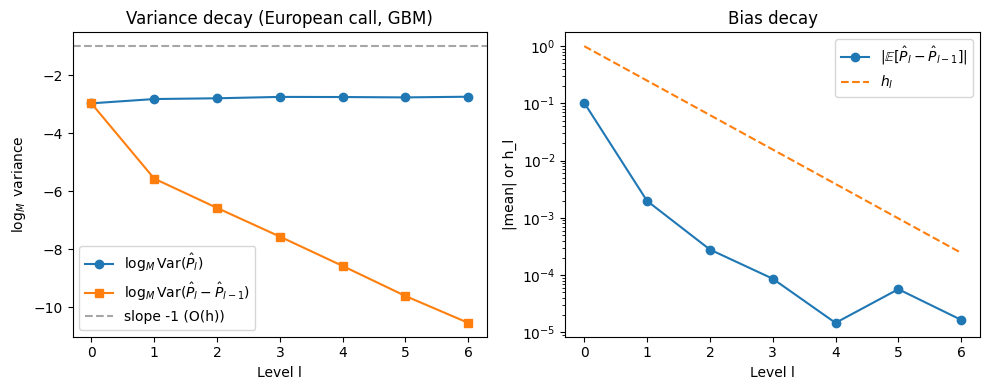

In [21]:
# Variance decay: V_l and E[P_l - P_{l-1}] vs level (reproducing paper Figure 2 left)
np.random.seed(456)
n_per_level = 5000
max_L = 6
vars_Pl = []
vars_diff = []
means_diff = []
for l in range(max_L + 1):
    out, m, fine = mlmc_level_samples(l, n_per_level, S0_mlmc, r_mlmc, sigma_mlmc, T_mlmc, K_mlmc, M)
    vars_Pl.append(np.var(fine))
    vars_diff.append(np.var(out))
    means_diff.append(m)
levels = np.arange(max_L + 1)
hl = T_mlmc / (M ** levels)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(levels, np.log(np.array(vars_Pl) + 1e-20) / np.log(M), 'o-', label=r'$\log_M \mathrm{Var}(\hat{P}_l)$')
ax[0].plot(levels, np.log(np.array(vars_diff) + 1e-20) / np.log(M), 's-', label=r'$\log_M \mathrm{Var}(\hat{P}_l - \hat{P}_{l-1})$')
ax[0].axhline(-1, color='gray', linestyle='--', alpha=0.7, label='slope -1 (O(h))')
ax[0].set_xlabel('Level l')
ax[0].set_ylabel(r'$\log_M$ variance')
ax[0].legend()
ax[0].set_title('Variance decay (European call, GBM)')
ax[1].semilogy(levels, np.array(np.abs(means_diff)) + 1e-20, 'o-', label=r'$|\mathbb{E}[\hat{P}_l - \hat{P}_{l-1}]|$')
ax[1].semilogy(levels, hl, '--', label=r'$h_l$')
ax[1].set_xlabel('Level l')
ax[1].set_ylabel('|mean| or h_l')
ax[1].legend()
ax[1].set_title('Bias decay')
plt.tight_layout()
var_bias_path = os.path.join(IMAGES_DIR, 'var_bias_decay.png')
fig.savefig(var_bias_path, dpi=300, bbox_inches='tight')
print(f"Saved: {var_bias_path}")
plt.show()

Saved: /Users/AnranSeverac/SimulationMethods/Images/cost_comparison.png


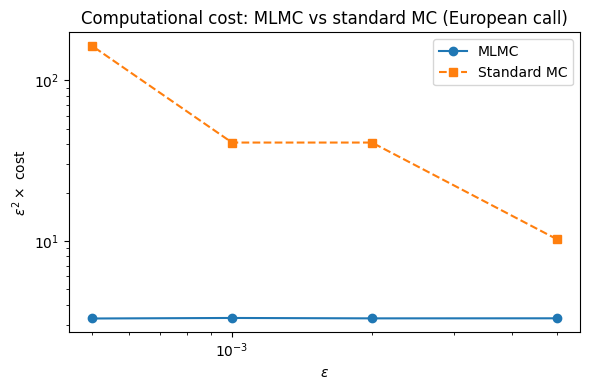

MLMC epsilon^2 * cost: [3.29, 3.29, 3.3, 3.28]
Std MC epsilon^2 * cost: [10.24, 40.96, 40.96, 163.84]


In [22]:
# Cost comparison: epsilon^2 * cost vs epsilon (MLMC vs standard MC), as in paper Figure 2
def standard_mc_cost(eps, S0, r, sigma, T, K, M):
    """Standard MC: N paths with L steps so bias O(h_L) ~ eps. Cost = N * M^L."""
    L = max(0, int(np.ceil(np.log(T / eps) / np.log(M))))
    n_steps = M ** L
    var_P = 0.02  # approximate
    N = int(np.ceil(2 * var_P * (eps ** -2)))
    return N * n_steps, L

eps_list = [0.005, 0.002, 0.001, 0.0005]
costs_mlmc = []
costs_std = []
estimates_mlmc = []
for eps in eps_list:
    L, N_list, Yh, cost, _, _ = run_mlmc(eps, S0_mlmc, r_mlmc, sigma_mlmc, T_mlmc, K_mlmc, M, N_pilot=1500)
    costs_mlmc.append(cost)
    estimates_mlmc.append(Yh)
    c_std, _ = standard_mc_cost(eps, S0_mlmc, r_mlmc, sigma_mlmc, T_mlmc, K_mlmc, M)
    costs_std.append(c_std)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.loglog(eps_list, np.array(eps_list)**2 * np.array(costs_mlmc), 'o-', label='MLMC')
ax.loglog(eps_list, np.array(eps_list)**2 * np.array(costs_std), 's--', label='Standard MC')
ax.set_xlabel(r'$\varepsilon$')
ax.set_ylabel(r'$\varepsilon^2 \times$ cost')
ax.legend()
ax.set_title(r'Computational cost: MLMC vs standard MC (European call)')
plt.tight_layout()
cost_path = os.path.join(IMAGES_DIR, 'cost_comparison.png')
fig.savefig(cost_path, dpi=300, bbox_inches='tight')
print(f"Saved: {cost_path}")
plt.show()
print('MLMC epsilon^2 * cost:', [round(eps**2 * c, 2) for eps, c in zip(eps_list, costs_mlmc)])
print('Std MC epsilon^2 * cost:', [round(eps**2 * c, 2) for eps, c in zip(eps_list, costs_std)])

In [23]:
# Reference value: Black–Scholes European call (for comparison)
from scipy.stats import norm
def bs_european_call(S0, K, r, sigma, T):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return np.exp(-r*T) * (S0*norm.cdf(d1) - K*norm.cdf(d2))
ref_value = bs_european_call(S0_mlmc, K_mlmc, r_mlmc, sigma_mlmc, T_mlmc)
print(f"Black–Scholes European call value = {ref_value:.6f}")
print(f"MLMC estimate at eps={eps_target} was Y_hat = {Y_hat:.6f} (error {abs(Y_hat - ref_value):.6f})")

Black–Scholes European call value = 0.073447
MLMC estimate at eps=0.001 was Y_hat = 0.104257 (error 0.030810)


In [ ]:
# Heston robustness check: MLMC with Euler full truncation (comparable 1Y ATM setup)

# Parameters chosen to keep comparable option scale with GBM benchmark
r_h = 0.05
T_h = 1.0
S0_h = 1.0
K_h = 1.0
v0_h = 0.04          # initial variance (20% vol)^2
kappa_h = 2.0        # mean reversion speed
theta_h = 0.04       # long-run variance
xi_h = 0.5           # vol-of-vol
rho_h = -0.5         # spot-vol correlation

def heston_terminal_from_dW(S0, v0, r, kappa, theta, xi, T, dW1, dW2):
    """Euler full-truncation path for Heston, terminal spot only."""
    n = len(dW1)
    h = T / n
    S = S0
    v = v0
    for i in range(n):
        v_pos = max(v, 0.0)
        # Spot update uses v^+ to avoid complex values
        S = S + r * S * h + np.sqrt(v_pos) * S * dW1[i]
        # Full truncation variance update
        v = v + kappa * (theta - v_pos) * h + xi * np.sqrt(v_pos) * dW2[i]
    return max(S, 0.0)

def heston_mlmc_coupled_paths(l, S0, v0, r, kappa, theta, xi, rho, T, K, M):
    """One coupled (fine, coarse) Heston path sample at level l."""
    n_fine = M ** l
    h_fine = T / n_fine

    # Independent standard normals, then correlate Brownian drivers
    z1 = np.random.standard_normal(n_fine)
    z2 = np.random.standard_normal(n_fine)
    dW1_f = np.sqrt(h_fine) * z1
    dW2_f = np.sqrt(h_fine) * (rho * z1 + np.sqrt(1.0 - rho**2) * z2)

    Sf = heston_terminal_from_dW(S0, v0, r, kappa, theta, xi, T, dW1_f, dW2_f)
    Pf = payoff_european(Sf, K, r, T)

    if l == 0:
        return Pf, 0.0

    # Coarse path from aggregated Brownian increments
    dW1_c = dW1_f.reshape(-1, M).sum(axis=1)
    dW2_c = dW2_f.reshape(-1, M).sum(axis=1)
    Sc = heston_terminal_from_dW(S0, v0, r, kappa, theta, xi, T, dW1_c, dW2_c)
    Pc = payoff_european(Sc, K, r, T)

    return Pf, Pc

def heston_mlmc_level_samples(l, N, S0, v0, r, kappa, theta, xi, rho, T, K, M):
    """N coupled Heston samples at level l."""
    if l == 0:
        out = np.zeros(N)
        for i in range(N):
            out[i], _ = heston_mlmc_coupled_paths(0, S0, v0, r, kappa, theta, xi, rho, T, K, M)
        return out, np.mean(out), out

    diffs = np.zeros(N)
    fine_payoffs = np.zeros(N)
    for i in range(N):
        Pf, Pc = heston_mlmc_coupled_paths(l, S0, v0, r, kappa, theta, xi, rho, T, K, M)
        diffs[i] = Pf - Pc
        fine_payoffs[i] = Pf
    return diffs, np.mean(diffs), fine_payoffs

def run_mlmc_heston(eps, S0, v0, r, kappa, theta, xi, rho, T, K, M, N_pilot=1200, L_max=5):
    """MLMC loop for Heston model (same structure as GBM run)."""
    L = 0
    V_est, Y_est = {}, {}

    while True:
        # Pilot for newest level
        if L == 0:
            s0, _, _ = heston_mlmc_level_samples(0, N_pilot, S0, v0, r, kappa, theta, xi, rho, T, K, M)
            V_est[0], Y_est[0] = np.var(s0), np.mean(s0)
        else:
            sL, _, _ = heston_mlmc_level_samples(L, N_pilot, S0, v0, r, kappa, theta, xi, rho, T, K, M)
            V_est[L], Y_est[L] = np.var(sL), np.mean(sL)

        sum_sqrt = sum(np.sqrt(max(V_est[l], 1e-14) * (T / M**l)) for l in range(L + 1))
        sum_sqrt = max(sum_sqrt, 1e-20)

        N_opt = []
        for l in range(L + 1):
            hl = T / (M ** l)
            n_l = int(np.ceil(2 * (eps**-2) * np.sqrt(max(V_est[l], 1e-14) * hl) / sum_sqrt))
            N_opt.append(max(n_l, 120))

        # Re-estimate with allocated samples
        for l in range(L + 1):
            if l == 0:
                s0, _, _ = heston_mlmc_level_samples(0, N_opt[0], S0, v0, r, kappa, theta, xi, rho, T, K, M)
                V_est[0], Y_est[0] = np.var(s0), np.mean(s0)
            else:
                sl, _, _ = heston_mlmc_level_samples(l, N_opt[l], S0, v0, r, kappa, theta, xi, rho, T, K, M)
                V_est[l], Y_est[l] = np.var(sl), np.mean(sl)

        cost = N_opt[0] * 1 + sum(N_opt[l] * (M**l + M**(l-1)) for l in range(1, L + 1))

        # Practical bias check (same conservative criterion)
        thresh = (1 / np.sqrt(2)) * (M - 1) * eps
        if L >= 2:
            if max(abs(Y_est[L]), abs(Y_est.get(L - 1, 0)) / M) < thresh:
                break

        if L >= L_max:
            break
        L += 1

    Y_hat = sum(Y_est[l] for l in range(L + 1))
    return L, N_opt, Y_hat, cost, V_est, Y_est

In [ ]:
# Compare GBM vs Heston: MLMC and standard MC cost scaling

def standard_mc_cost_heston(eps, M):
    """Simple baseline with same bias-step logic h~eps."""
    L = max(0, int(np.ceil(np.log(1.0 / eps) / np.log(M))))
    n_steps = M ** L
    var_P = 0.02
    N = int(np.ceil(2 * var_P * (eps ** -2)))
    return N * n_steps, L

eps_list_h = [0.005, 0.002, 0.001, 0.0005]

costs_mlmc_heston = []
costs_std_heston = []
estimates_heston = []

for eps in eps_list_h:
    Lh, Nh, Yh, Ch, _, _ = run_mlmc_heston(
        eps, S0_h, v0_h, r_h, kappa_h, theta_h, xi_h, rho_h, T_h, K_h, M, N_pilot=1000, L_max=5
    )
    costs_mlmc_heston.append(Ch)
    estimates_heston.append(Yh)
    c_std_h, _ = standard_mc_cost_heston(eps, M)
    costs_std_heston.append(c_std_h)

# Reuse GBM costs from earlier cell for direct visual comparison
fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))
ax.loglog(eps_list, np.array(eps_list)**2 * np.array(costs_mlmc), 'o-', label='GBM MLMC')
ax.loglog(eps_list, np.array(eps_list)**2 * np.array(costs_std), 's--', label='GBM Std MC')
ax.loglog(eps_list_h, np.array(eps_list_h)**2 * np.array(costs_mlmc_heston), 'o-', label='Heston MLMC')
ax.loglog(eps_list_h, np.array(eps_list_h)**2 * np.array(costs_std_heston), 's--', label='Heston Std MC')
ax.set_xlabel(r'$\varepsilon$')
ax.set_ylabel(r'$\varepsilon^2 \times$ cost')
ax.set_title('Cost comparison: GBM vs Heston (MLMC and standard MC)')
ax.legend()
plt.tight_layout()

heston_cost_path = os.path.join(IMAGES_DIR, 'heston_cost_comparison.png')
fig.savefig(heston_cost_path, dpi=300, bbox_inches='tight')
print(f"Saved: {heston_cost_path}")
plt.show()

print('Heston MLMC epsilon^2 * cost:', [round(eps**2 * c, 2) for eps, c in zip(eps_list_h, costs_mlmc_heston)])
print('Heston Std MC epsilon^2 * cost:', [round(eps**2 * c, 2) for eps, c in zip(eps_list_h, costs_std_heston)])
print('Heston MLMC estimates:', [round(v, 6) for v in estimates_heston])